In [ ]:
import pandas as pd 
df_test = pd.read_csv("C:/Users/chahd/Desktop/projet_Data_mining/test.csv")
df_train = pd.read_csv("C:/Users/chahd/Desktop/projet_Data_mining/train.csv")                                                                                                                                                                                                                                                                                                                       

## Loading the Data

In this cell, we import the **pandas** library and load the **training** and **test** datasets from locally stored CSV files.

In [ ]:
df_train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Overview of the Training Dataset

In this cell, we display the first **5 rows** of the **training** dataset df_train using the **head()** function.
This allows us to get an initial look at the available variables and their formats. 
The dataset provides information about a sample of Titanic passengers, including personal and socio-economic data.

The goal is to use this information to **predict** **the probability of survival** of a passenger based on certain characteristics.

## Dataset Features

- **PassengerId** : Unique identifier of the passenger.

- **Survived** : Survival indicator (0 = No, 1 = Yes).

- **Pclass** : Ticket class (1st, 2nd, or 3rd).

- **Name** : Full name of the passenger.

- **Sex** : Gender of the passenger.

- **Age** : Age of the passenger.

- **SibSp** : Number of siblings and spouses aboard.

- **Parch** : Number of parents and children aboard.

- **Ticket** : Ticket number.

- **Fare** : Fare paid for the ticket.

- **Cabin** (sometimes missing).

- **Embarked** : Port of embarkation (C = Cherbourg, Q = Queenstown, S = Southampton).




In [ ]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


## General Information About the Training Dataset

In this cell, we use the info() method to display general information about the df_train DataFrame, including:

- Total number of rows and columns,

- Column names,

- Number of non-null values per column,

- Data type of each column (int, float, object, etc.).

This step provides an overview of the data structure and helps quickly identify missing values.

In [ ]:
nan_percentage = df_test.isna().mean() * 100
print(nan_percentage)

PassengerId     0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            20.574163
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.239234
Cabin          78.229665
Embarked        0.000000
dtype: float64


## Percentage of Missing Values in the Test Dataset

In this cell, we calculate the percentage of missing values for each column in the df_test DataFrame.
The method used is:

- isna(): detects missing values,

- mean(): calculates the proportion of missing values,

- Multiply by 100 to obtain a percentage.

This helps identify which columns require special handling for missing data.

In [ ]:
df_test.drop("Cabin", axis=1, inplace=True)

## Deletion of the "Cabin" Column

The Cabin column contains about **78% missing values**, which is very high.
Instead of trying to fill or use it, we choose to remove this column from the df_test dataset to simplify the analysis and improve model quality.

The deletion is performed using the drop() method, specifying:

- "Cabin" as the column to delete,

- axis=1 to indicate columns (not rows),

- inplace=True to modify df_test directly without creating a copy.

In [ ]:
average_age = df_test.groupby(['Pclass', 'Sex'])['Age'].mean()
print(average_age)

Pclass  Sex   
1       female    41.333333
        male      40.520000
2       female    24.376552
        male      30.940678
3       female    23.073400
        male      24.525104
Name: Age, dtype: float64


## Average Age by Class and Gender

In this cell, we calculate the **average age** of passengers based on their **class** (Pclass) and **gender** (Sex) in the df_test dataset.

The method used:

- groupby(['Pclass', 'Sex']): groups data by class and gender,

- ['Age'].mean(): calculates the mean age for each group.

This helps **impute missing ages** more accurately based on passenger profile (class + gender).

In [ ]:
def fill_age(row):
    if pd.isnull(row['Age']):
        return average_age.loc[row['Pclass'], row['Sex']]
    else:
        return row['Age']

df_test['Age'] = df_test.apply(fill_age, axis=1)


## Filling Missing Ages

In this cell, we create a function fill_age(row) to **replace missing values** in the Age column:

- If age is missing (NaN), the function assigns the **average age** corresponding to the passenger’s class (Pclass) and gender (Sex) calculated earlier.

- Otherwise, it keeps the existing age.

Then, we apply this function to each row in the df_test DataFrame using apply(axis=1) to correct missing Age values.

In [ ]:
df_test['Fare'].fillna(df_test['Fare'].mean(), inplace=True)

C:\Users\chahd\AppData\Local\Temp\ipykernel_8844\1576205081.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_test['Fare'].fillna(df_test['Fare'].mean(), inplace=True)


## Filling Missing Values in the "Fare" Column

In this cell, we fill the missing values in the Fare column with the **average** fare in the df_test dataset.

**Why use the mean?**

There are only a few missing values for Fare, so the impact is minimal.



## Processing the Training Dataset (train)

We apply the same preprocessing steps to the df_train dataset as we did to df_test, ensuring consistency between both datasets.

In [ ]:
nan2_percentage = df_train.isna().mean() * 100
print(nan2_percentage)

PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            19.865320
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.224467
dtype: float64


In [ ]:
df_train.drop("Cabin", axis=1, inplace=True)

In [ ]:
average1_age = df_train.groupby(['Pclass', 'Sex'])['Age'].mean()
print(average1_age)

Pclass  Sex   
1       female    34.611765
        male      41.281386
2       female    28.722973
        male      30.740707
3       female    21.750000
        male      26.507589
Name: Age, dtype: float64


In [ ]:
def fill_age(row):
    if pd.isnull(row['Age']):
        return average1_age.loc[row['Pclass'], row['Sex']]
    else:
        return row['Age']

df_train['Age'] = df_train.apply(fill_age, axis=1)

In [ ]:
df_train['Fare'].fillna(df_train['Fare'].mean(), inplace=True)

C:\Users\chahd\AppData\Local\Temp\ipykernel_8844\3221546853.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_train['Fare'].fillna(df_train['Fare'].mean(), inplace=True)


In [ ]:
embarked_mode = df_train['Embarked'].mode()[0]
df_train['Embarked'].fillna(embarked_mode, inplace=True)

C:\Users\chahd\AppData\Local\Temp\ipykernel_8844\1398243356.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_train['Embarked'].fillna(embarked_mode, inplace=True)


In [ ]:
df_train.dtypes


PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Embarked        object
dtype: object

In [ ]:
df_test.dtypes

PassengerId      int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Embarked        object
dtype: object

In [ ]:
df_train['Sex'] = df_train['Sex'].map({'male': 0, 'female': 1})
df_test['Sex'] = df_test['Sex'].map({'male': 0, 'female': 1})

## Transforming the "Sex" Column into Numeric Variables

In this cell, we transform the Sex column (which contains categorical values 'male' and 'female') into **numeric variables** for use in machine learning models.

The transformation:

- 'male' becomes 0

- 'female' becomes 1

In [ ]:
df_train['Embarked'] = df_train['Embarked'].map({'S': 0, 'C': 1,'Q':2})
df_test['Embarked'] = df_test['Embarked'].map({'S': 0, 'C': 1,'Q':2})

## Transforming the "Embarked" Column into Numeric Variables

In this cell, we transform the Embarked column (which contains categorical values representing ports of embarkation: 'S', 'C', 'Q') into numeric variables.

Transformations applied:

- 'S' becomes 0

- 'C' becomes 1

- 'Q' becomes 2

This conversion is done using the map() method, which replaces column values according to a dictionary.

In [ ]:
df_train_no_pid = df_train.drop(columns=['PassengerId','Name','Ticket'])
correlation_matrix = df_train_no_pid.corr()
survived_correlation_values = correlation_matrix['Survived']

## Removing Irrelevant Columns and Computing the Correlation Matrix

In this cell, we perform two key steps:

1. **Removing irrelevant columns**:We remove the columns PassengerId, Name, and Ticket from the df_train dataset, as they contain no useful predictive information for survival.

2. **Computing the correlation matrix**:
Then, we compute the correlation matrix on df_train_no_pid to analyze relationships between numeric variables.
The corr() method computes the Pearson correlation coefficient between variables.

3. **Extracting correlation values with Survived**:
Finally, we extract correlation values for the target column Survived.
This helps identify which variables have the strongest (positive or negative) relationship with survival.

In [ ]:
correlation_matrix = df_train.drop(columns=['PassengerId','Name','Ticket']).corr()
correlation_with_survived = correlation_matrix['Survived']
print(correlation_with_survived)

Survived    1.000000
Pclass     -0.338481
Sex         0.543351
Age        -0.067485
SibSp      -0.035322
Parch       0.081629
Fare        0.257307
Embarked    0.106811
Name: Survived, dtype: float64


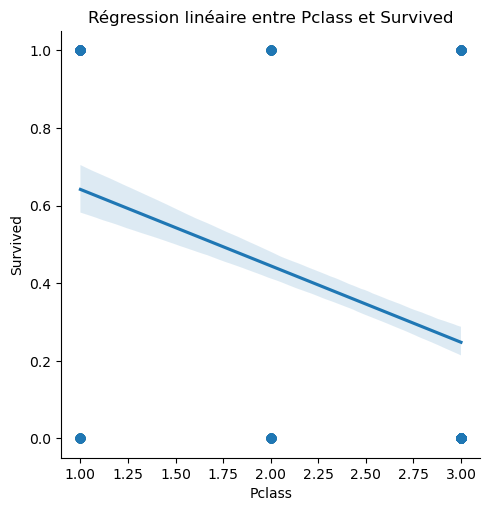

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.lmplot(x='Pclass', y='Survived', data=df_train, logistic=False)
plt.title('Régression linéaire entre Pclass et Survived')
plt.show()

## Interpretation of the Linear Regression Plot Between Pclass and Survived

This graph represents the relationship between ticket class (Pclass) and passenger survival (Survived) on the Titanic.

**Blue Points**

- Each blue point represents a passenger.

- X-axis: ticket class (Pclass) — 1 = 1st class, 2 = 2nd, 3 = 3rd.

- Y-axis: survival status (Survived) — 0 = did not survive, 1 = survived.

- Points appear at y = 0 or y = 1, showing the real data (each person survived or not).

- Blue Line (Linear Regression)

- Represents a simple linear regression showing the general trend between Pclass and Survived.

- The slope is negative, meaning lower classes had lower survival chances.

- The line doesn’t go through all points, as it represents the average predicted value per class.

**Light Blue Confidence Band**

- A **95% confidence interval** around the regression line.

- Shows uncertainty of the mean prediction — narrower = more reliable prediction.

**Visual Conclusion**

- **1st-class passengers** are more often found at y = 1 (survivors).

- **3rd-class passengers** are mostly at y = 0 (non-survivors).

- There is a **negative linear relationship** between Pclass and Survived.

**Correlation Connection**

Since the regression slope (β₁) is negative, the correlation coefficient r is also negative, confirming the decreasing linear relationship.







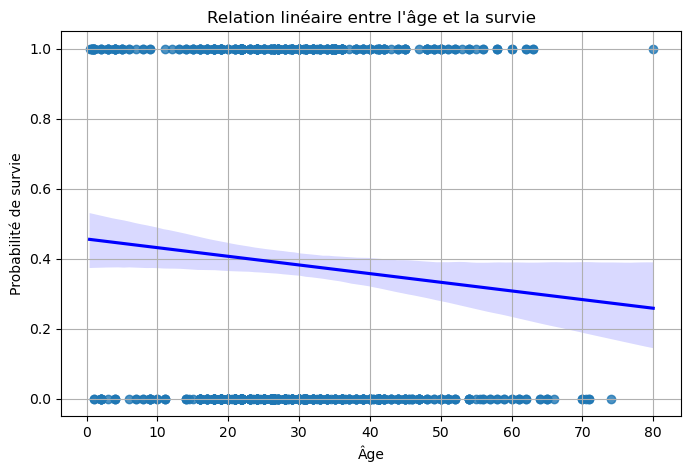

In [ ]:
plt.figure(figsize=(8, 5))

# Tracer la droite de régression
sns.regplot(x='Age', y='Survived', data=df_train, logistic=False, ci=95, line_kws={'color':'blue'})

# Titre et étiquettes
plt.title("Relation linéaire entre l'âge et la survie")
plt.xlabel("Âge")
plt.ylabel("Probabilité de survie")

# Afficher le graphique
plt.grid(True)
plt.show()

## Interpretation of the Linear Regression Plot Between Age and Survival

This graph shows the relationship between passenger age and survival probability.

**Blue Points**

- Each point = a passenger.

- X-axis = Age.

- Y-axis = Survived (0 = not survived, 1 = survived).

- Points appear at y = 0 or y = 1, representing actual outcomes.

**Blue Line (Linear Regression)**

- A simple linear regression line showing the overall trend between age and survival.

- The slope is negative, meaning the older the passenger, the lower the survival probability.

**Light Blue Confidence Band**

- Represents a **95% confidence interval** around the regression line.

- Narrower = more accurate mean prediction.

**Visual Conclusion**

- Younger passengers (children) had a higher survival rate.

- Older passengers were more often non-survivors.

- There’s a negative linear relationship between age and survival.

**Correlation Connection**

Since the regression slope (β₁) is negative, the correlation r is also negative, confirming that older passengers were less likely to survive.

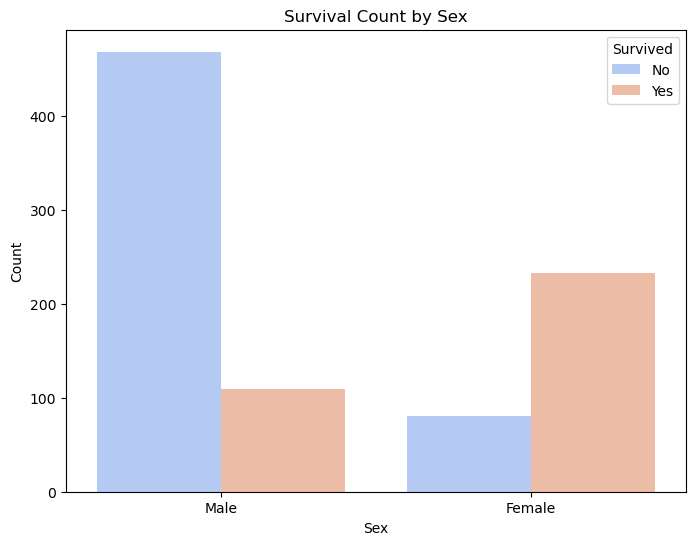

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.countplot(data=df_train, x='Sex', hue='Survived', palette='coolwarm')
plt.title('Survival Count by Sex')
plt.xlabel('Sex')
plt.xticks([0, 1], ['Male', 'Female'])
plt.ylabel('Count')
plt.legend(title='Survived', labels=['No', 'Yes'])
plt.show()


### 1. Survival Count by Sex

This graph shows the distribution of survivors and non-survivors by gender.
We can observe that:

- Most men did not survive.

- In contrast, most women survived.

**Interpretation**:
Gender had a strong impact on survival chances, with a clear advantage for women.

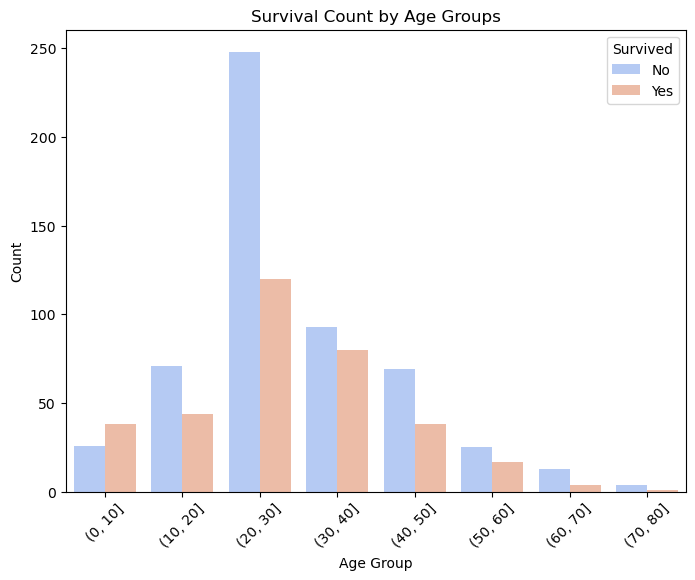

In [ ]:
age_bins = [0, 10, 20, 30, 40, 50, 60, 70, 80]
df_train['Age_binned'] = pd.cut(df_train['Age'], bins=age_bins)

plt.figure(figsize=(8, 6))
sns.countplot(data=df_train, x='Age_binned', hue='Survived', palette='coolwarm')
plt.title('Survival Count by Age Groups')
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Survived', labels=['No', 'Yes'])
plt.show()

### 2. Survival Count by Age Groups

This graph shows survival by age group.
We can observe that:

- Young children (0–10 years) had better survival chances than older adults.

- The 20–30 age group had the highest number of deaths.

- From age 50 onward, survival rates became very low.

Interpretation:
Age influenced survival — children were better protected, while young adults faced higher risks.



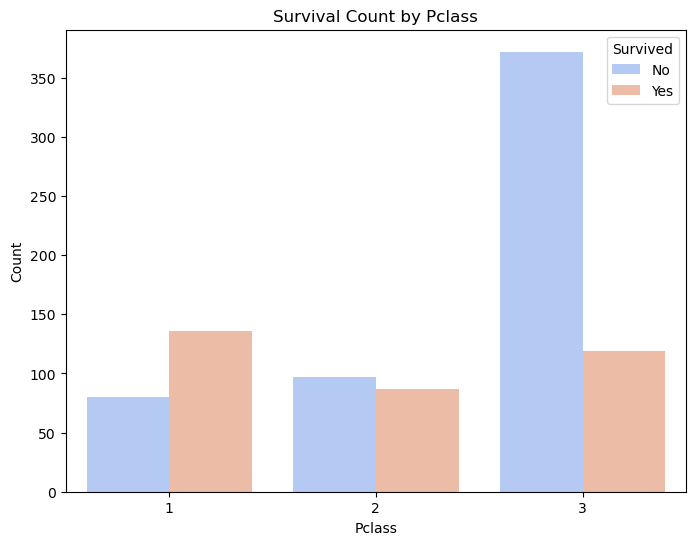

In [ ]:
plt.figure(figsize=(8, 6))
sns.countplot(data=df_train, x='Pclass', hue='Survived', palette='coolwarm')
plt.title('Survival Count by Pclass')
plt.xlabel('Pclass')
plt.ylabel('Count')
plt.legend(title='Survived', labels=['No', 'Yes'])
plt.show()

### 3. Survival Count by Pclass

This graph represents survival according to ticket class (Pclass).
We can see that:

- First-class passengers had a higher probability of survival.

- Third-class passengers experienced a very high mortality rate.

- Second-class passengers fall between the two extremes.

**Interpretation**:
Social class played a crucial role in survival, with first-class passengers being prioritized during rescue operations.

### Summary: Who Are the Survivors?

Typical profile of a **survivor**:

- A woman,

- In 1st class,

- Rather young or a child.

Typical profile of a **victim**:

- A man,

- In 3rd class,

- Often an adult or elderly person.


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

## Importing Libraries

Here we import the necessary libraries for **data preparation**, **machine learning model building**, and **performance evaluation**:

- train_test_split: to split the dataset into training and test sets.

- StandardScaler: to normalize (standardize) the features, giving them zero mean and unit variance.

- DecisionTreeClassifier: to build a decision tree model.

- SVC (Support Vector Classifier): to build a support vector machine (SVM) model.

- KNeighborsClassifier: to build a k-nearest neighbors (KNN) model.

- accuracy_score: to evaluate model performance by calculating accuracy.

In [ ]:
features = ['Pclass', 'Sex', 'Age', 'Fare', 'Embarked']
X_train = df_train[features]
y_train = df_train['Survived']
X_test = df_test[features]

# 5. Normalisation des données
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 6. Entraînement du modèle Arbre de Décision
dt_model = DecisionTreeClassifier()
dt_model.fit(X_train_scaled, y_train)

# 7. Évaluation du modèle sur l'ensemble d'entraînement
y_pred_train = dt_model.predict(X_train_scaled)
accuracy_train = accuracy_score(y_train, y_pred_train)
print(f"Précision du modèle Arbre de Décision sur l'ensemble d'entraînement : {accuracy_train:.4f}")

Précision du modèle Arbre de Décision sur l'ensemble d'entraînement : 0.9798


## Feature Selection

The following variables were selected as input features to train our model:

- Pclass: Passenger ticket class (1st, 2nd, or 3rd class).

- Sex: Passenger’s sex, an important factor from the exploratory analysis.

- Age: Passenger’s age, which also affects survival chances.

- Fare: Ticket fare, often correlated with socio-economic status.

- Embarked: Port of embarkation, which may indirectly reflect socio-economic conditions.

**Why these features?**
These variables were chosen because they are relevant and showed correlation with survival during exploratory analysis. They are also interpretable and allow training an efficient model without overloading it with unnecessary variables.

---

## Data Preparation

- X_train contains the training data with the selected features.

- y_train contains the target variable (Survived) indicating whether a passenger survived or not.

- X_test contains the test data with the same features.

---

## Data Normalization

Before training the model, we normalize (X_train and X_test) using StandardScaler to:

- Speed up the convergence of certain algorithms.

- Ensure that each feature contributes equally to distance calculations (especially important for SVM and KNN).
---

## Decision Tree Model Training

We use a DecisionTreeClassifier to:

- Model decisions based on simple and interpretable rules.

- Capture non-linear relationships between variables and survival.

---

## Model Evaluation

We evaluate model performance on the training set using accuracy_score, which measures the proportion of correct predictions.

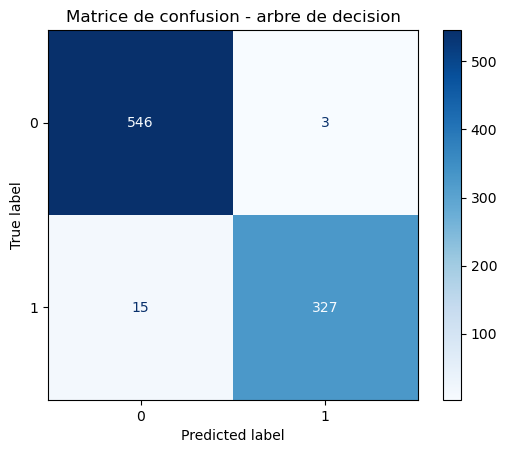

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Prédictions sur l'ensemble d'entraînement
y_pred_train = dt_model.predict(X_train_scaled)

# Calcul de la matrice de confusion
cm = confusion_matrix(y_train, y_pred_train)

# Affichage de la matrice de confusion
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=dt_model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Matrice de confusion - arbre de decision")
plt.show()


## Confusion Matrix – Model Evaluation

To better assess the Decision Tree model’s performance, we use a **confusion matrix** :

- confusion_matrix: compares true labels (y_train) with predicted ones (y_pred_train).

- ConfusionMatrixDisplay: displays the confusion matrix graphically.

- cmap=plt.cm.Blues: uses a blue color map for better readability.

**Confusion Matrix Interpretation**

- 327 passengers correctly predicted as survivors (true positives).

- 546 passengers correctly predicted as non-survivors (true negatives).

- 13 passengers incorrectly predicted as non-survivors but actually survived (false negatives).

- 3 passengers incorrectly predicted as survivors but did not survive (false positives).

**Summary**:

- The model performs very well at predicting non-survivors.

- It makes very few overall errors, with a low number of false positives and false negatives.

- Most survivors and non-survivors were correctly classified.

This indicates that the **Decision Tree model** is accurate and balanced on the training set.

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Entraînement du modèle SVM
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm_model.fit(X_train_scaled, y_train)

# Prédiction sur l'ensemble d'entraînement
y_pred_svm = svm_model.predict(X_train_scaled)

# Évaluation du modèle
accuracy_svm = accuracy_score(y_train, y_pred_svm)
print(f"Model accuracy: {accuracy_svm:.4f}")

Précision du modèle SVM sur l'ensemble d'entraînement : 0.8294


## Training and Evaluating an SVM Model

Here we use a Support Vector Machine (SVM) for classification.

**Parameters Used**:

- kernel='rbf': radial basis kernel to capture non-linear relationships.

- C=1.0: regularization parameter; higher C reduces margin but improves training accuracy.

- gamma='scale': automatically adjusts gamma based on the number of features.

- random_state=42: ensures reproducibility.

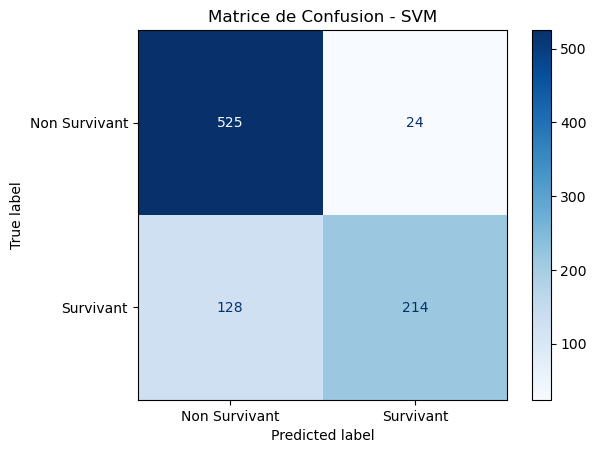

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Prédictions sur l'ensemble d'entraînement
y_pred_svm = svm_model.predict(X_train_scaled)

# Génération de la matrice de confusion
cm_svm = confusion_matrix(y_train, y_pred_svm)

# Affichage de la matrice de confusion
disp_svm = ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=['Non Survivant', 'Survivant'])
disp_svm.plot(cmap=plt.cm.Blues)
plt.title('Matrice de Confusion - SVM')
plt.show()

## Confusion Matrix – SVM Model

SVM confusion matrix analysis shows:

- 214 passengers correctly predicted as survivors (true positives).

- 525 passengers correctly predicted as non-survivors (true negatives).

- 128 passengers incorrectly predicted as non-survivors but actually survived (false negatives).

- 24 passengers incorrectly predicted as survivors but did not survive (false positives).

**Summary**:

- The model correctly identifies most non-survivors.

- However, it struggles to predict survivors (many false negatives).

- It tends to be conservative, favoring “non-survival” when uncertain.

**Conclusion**:

- The model has good overall accuracy, but low recall for survivors (misses many survivors).

- Adjusting parameters like C or using class_weight='balanced' could help detect survivors better.

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.1, 1],
    'kernel': ['rbf', 'linear', 'poly']
}


grid_search = GridSearchCV(SVC(), param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train_scaled, y_train)


best_params = grid_search.best_params_

svm_model = grid_search.best_estimator_


y_pred_svm = svm_model.predict(X_train_scaled)

accuracy_svm = accuracy_score(y_train, y_pred_svm)
print(f"Précision du modèle SVM sur l'ensemble d'entraînement : {accuracy_svm:.4f}")

Précision du modèle SVM sur l'ensemble d'entraînement : 0.8294


## Hyperparameter Optimization with GridSearchCV – SVM

Search performed on parameters:

- C: [0.1, 1, 10, 100]

- gamma: ['scale', 'auto', 0.1, 1]

- kernel: ['rbf', 'linear', 'poly']

**GridSearchCV Setup**:

- Cross-validation: cv=5

- Scoring metric: accuracy

- Parallel processing: n_jobs=-1

**Results**

Best parameters found:

- best_params = grid_search.best_params_

- Model retrained with best parameters.

**Accuracy Analysis**:

- Even after optimization, the model’s accuracy remained almost the same as before.

**Interpretation**:

- The model was already near its optimal performance.

- The Titanic dataset is simple and well-separated, so fine-tuning doesn’t yield large improvements.

- Hyperparameter optimization is more useful for complex datasets.





In [ ]:
from sklearn.neighbors import KNeighborsClassifier

# Entraînement du modèle KNN
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)

# Prédiction sur l'ensemble d'entraînement
y_pred_knn = knn_model.predict(X_train_scaled)

# Évaluation du modèle
accuracy_knn = accuracy_score(y_train, y_pred_knn)
print(f"Précision du modèle KNN sur l'ensemble d'entraînement : {accuracy_knn:.4f}")

Précision du modèle KNN sur l'ensemble d'entraînement : 0.8709


In [ ]:
from sklearn.neighbors import KNeighborsClassifier

# Entraînement du modèle KNN
knn_model = KNeighborsClassifier(n_neighbors=6)
knn_model.fit(X_train_scaled, y_train)

# Prédiction sur l'ensemble d'entraînement modifier k avec validation croisee 
y_pred_knn = knn_model.predict(X_train_scaled)

# Évaluation du modèle
accuracy_knn = accuracy_score(y_train, y_pred_knn)
print(f"Précision du modèle KNN sur l'ensemble d'entraînement : {accuracy_knn:.4f}")

Précision du modèle KNN sur l'ensemble d'entraînement : 0.8631


In [ ]:
from sklearn.neighbors import KNeighborsClassifier

# Entraînement du modèle KNN
knn_model = KNeighborsClassifier(n_neighbors=7)
knn_model.fit(X_train_scaled, y_train)

# Prédiction sur l'ensemble d'entraînement modifier k avec validation croisee 
y_pred_knn = knn_model.predict(X_train_scaled)

# Évaluation du modèle
accuracy_knn = accuracy_score(y_train, y_pred_knn)
print(f"Précision du modèle KNN sur l'ensemble d'entraînement : {accuracy_knn:.4f}")

Précision du modèle KNN sur l'ensemble d'entraînement : 0.8597


## KNN Model Analysis on the Titanic Dataset

**General Parameters**:

- Model used: KNeighborsClassifier

- Number of features: 6

- Data preprocessed with normalization/scaling.

**Accuracy Results by k**
Number of Neighbors (k)  |	Training Accuracy
5	                     |  0.8709
6	                     |  0.8631
7	                     |  0.8597

**Analysis**

- Best accuracy (87.09%) achieved with k = 5.

- Increasing k to 6 or 7 slightly decreases accuracy.

**Why?**
Increasing k smooths the model (less sensitive to local variations).
This may cause additional errors if neighbors are not aligned with the correct class.

**Conclusion**
- For this Titanic dataset with 6 features,
- k = 5 offers the best balance between complexity and accuracy.



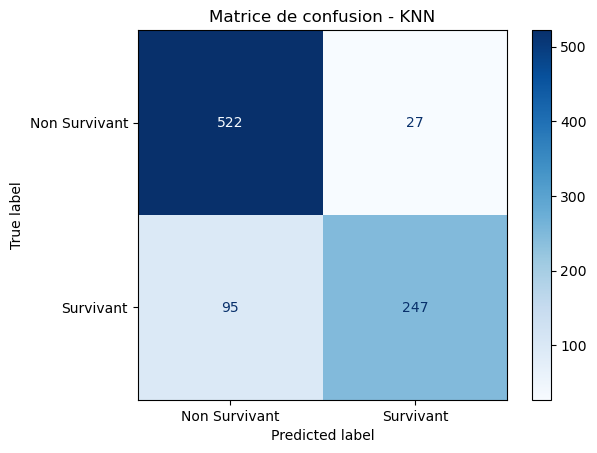

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Prédictions sur l'ensemble d'entraînement
y_pred_knn = knn_model.predict(X_train_scaled)

# Calcul de la matrice de confusion
cm_knn = confusion_matrix(y_train, y_pred_knn)

# Affichage de la matrice de confusion
disp_knn = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=['Non Survivant', 'Survivant'])
disp_knn.plot(cmap='Blues')
plt.title("Matrice de confusion - KNN")
plt.show()

## Confusion Matrix Analysis - KNN Model

**Key results**:

- 247 passengers were correctly predicted as survivors.

- 522 passengers were correctly predicted as non-survivors.

- 95 passengers were survivors but were predicted as non-survivors (false negatives).

- 27 passengers were non-survivors but were predicted as survivors (false positives).

**Analysis**:

- The model shows a good overall ability to distinguish survivors from non-survivors.

- However, there is a significant number of false negatives (95 survivors misclassified).

- This means many survivors are not correctly detected, which can be critical depending on the prediction objective.

**Remarks**:

- The model is more effective at recognizing non-survivors.

- Alternatively, you could adjust class handling (for example, with a higher weight for survivors).

**Conclusion**

The KNN model performs well, but efforts should be made to reduce the number of misclassified survivors to improve its relevance in critical situations.





## Why Does the Decision Tree Give the Best Results?

**Strengths of the Decision Tree**:

- Very good at handling categorical variables (like Sex or Pclass).

- Able to capture simple and direct rules (example: “if woman and 1st class → likely survival”).

- No need for scaling (unlike KNN and SVM).

- The decision tree is natural for this problem because it can easily separate data based on simple logical criteria.

## Why Does KNN Perform Worse?

**Weaknesses of KNN**:

- Sensitive to feature scales: even after normalization, some distances may not reflect the true logic (being male or female is not an easily measurable distance).

- Problem with unbalanced classes: KNN is influenced by the majority neighbors.

- Performs worse on data where the “logic” is global rather than local (as in this dataset with rule-based decisions).

## Why Is SVM Also Less Efficient?

**Weaknesses of SVM**:

- Not naturally suited for categorical variables (it prefers continuous numerical variables).

- Hard to separate when classes are not perfectly distinct (males and females, but also 1st, 2nd, 3rd class mixed).

- Parameter tuning (C, gamma) is complex for this type of small dataset.

## Final Conclusion

- Decision Tree ➔ Best choice for Titanic because survival rules are simple and clear (sex, class, age).

- KNN ➔ Less effective because distances don’t capture survival logic well.

- SVM ➔ Less effective because separating with hyperplanes is difficult on this dataset.